# Phase 2: Shortage Listing Survival Analysis

Original goal: Kaplan-Meier estimate of time from a shortage's onset to
being marked a permanent discontinuation. That turned out not to be
supportable from this data - see the methodology note in
`src/duration_model.py` and the writeup below. This notebook documents
that finding, then runs the reframed, honest version of the analysis.

In [1]:
import sys
sys.path.insert(0, "src")
import pandas as pd
from data_prep import load_shortages, add_supplier_concentration
from duration_model import (
    build_survival_dataset, fit_km, median_survival_days,
    survival_probability_at, km_by_group, elapsed_age_by,
)

## Why the original plan didn't work

The plan was: duration = `discontinued_date - initial_posting_date`,
event = status is "To Be Discontinued", "Current" = censored. Checking
that against the raw data first:

In [2]:
df_raw = load_shortages()
tbd = df_raw[df_raw["status"] == "To Be Discontinued"]
same_day = (tbd["discontinued_date"] == tbd["initial_posting_date"]).sum()
print(f"discontinued_date == initial_posting_date for {same_day} of {len(tbd)} "
      f"'To Be Discontinued' rows ({same_day/len(tbd):.1%})")

discontinued_date == initial_posting_date for 440 of 443 'To Be Discontinued' rows (99.3%)


That confirms it: a "To Be Discontinued" entry is posted as a brand-new
feed record on the day the discontinuation becomes public - not an
update to a `Current` entry that had been open for a while. With only
one snapshot of the feed, there's no way to see whatever shortage
period (if any) came before it. `initial_posting_date` here means "when
this discontinuation notice appeared," not "when the underlying
shortage began."

So the phase is reframed around **current status data**: for every row
we know how long it's been on the feed as of the snapshot
(`days_since_posted`), and whether it has, by the snapshot date,
already reached a final determination (discontinued or resolved) versus
still being open and undecided (`Current` - right-censored). That
supports an honest question: *of listings that have been visible for
at least X days, what share have already reached a final determination
vs. are still open?*

In [3]:
df = build_survival_dataset()
print(f"{len(df)} rows, {df['event'].sum()} already at a final determination "
      f"({df['event'].mean():.1%}), {1 - df['event'].mean():.1%} still open/censored")

1603 rows, 450 already at a final determination (28.1%), 71.9% still open/censored


## Overall Kaplan-Meier curve

In [4]:
km_all = fit_km(df)
med = median_survival_days(km_all)
print("median time to a final determination:",
      "not reached (most listings still undecided)" if med is None else f"{med:.0f} days")
for d in [30, 90, 180, 365, 730]:
    print(f"  P(still undecided after {d} days on the feed): {survival_probability_at(km_all, d):.3f}")

median time to a final determination: not reached (most listings still undecided)
  P(still undecided after 30 days on the feed): 0.982
  P(still undecided after 90 days on the feed): 0.933
  P(still undecided after 180 days on the feed): 0.875
  P(still undecided after 365 days on the feed): 0.726
  P(still undecided after 730 days on the feed): 0.722


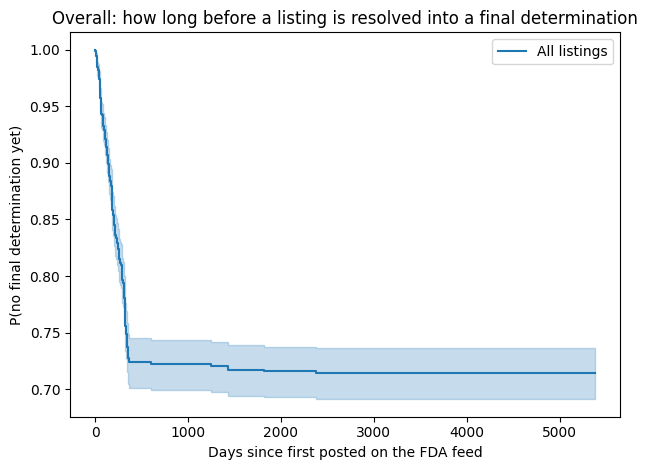

In [5]:
ax = km_all.plot_survival_function()
ax.set_xlabel("Days since first posted on the FDA feed")
ax.set_ylabel("P(no final determination yet)")
ax.set_title("Overall: how long before a listing is resolved into a final determination")
ax.figure.tight_layout()

## By supplier concentration

Phase 1 found supplier concentration was the dominant driver of
discontinuation risk. If that's real, listings with few alternative
suppliers should also reach a final determination *faster*, not just
more *often*. This is a genuinely independent check, using a different
method on the same underlying signal.

In [6]:
fits, test = km_by_group(df, "supplier_tier", min_group_size=30)
print(f"log-rank test across tiers: p = {test.p_value:.2e}\n")
for g, km in fits.items():
    m = median_survival_days(km)
    print(f"{g}: median = {'not reached' if m is None else f'{m:.0f} days'}, "
          f"P(still undecided after 1yr) = {survival_probability_at(km, 365):.3f}")

log-rank test across tiers: p = 1.39e-239

3-8 (moderate): median = not reached, P(still undecided after 1yr) = 0.940
1-2 (concentrated): median = 260 days, P(still undecided after 1yr) = 0.257
9+ (many suppliers): median = not reached, P(still undecided after 1yr) = 0.959


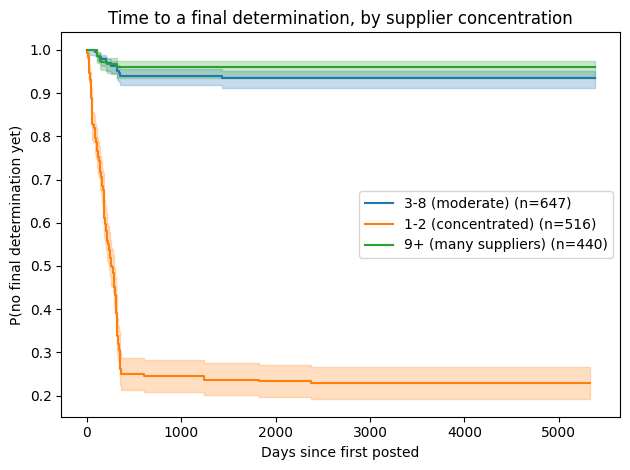

In [7]:
ax = None
for g, km in fits.items():
    ax = km.plot_survival_function(ax=ax)
ax.set_xlabel("Days since first posted")
ax.set_ylabel("P(no final determination yet)")
ax.set_title("Time to a final determination, by supplier concentration")
ax.figure.tight_layout()

Confirms it clearly: the "1-2 suppliers" tier reaches a final
determination in a median of ~260 days, and by one year only ~26% are
still undecided. The "3-8" and "9+" tiers barely move off 1.0 in the
same window - the vast majority just stay `Current`, open-ended, for
years. Supplier concentration doesn't just predict *whether* a listing
ends in discontinuation (Phase 1) - it predicts *how fast* that gets
decided at all.

## By therapeutic category

In [8]:
fits_cat, test_cat = km_by_group(df, "therapeutic_category", min_group_size=30)
print(f"log-rank test across categories: p = {test_cat.p_value:.2e}\n")
for g, km in fits_cat.items():
    m = median_survival_days(km)
    print(f"{g}: median = {'not reached' if m is None else f'{m:.0f} days'}")

log-rank test across categories: p = 6.57e-56

Anesthesia: median = not reached
Psychiatry: median = not reached
Cardiovascular: median = not reached
Analgesia/Addiction: median = not reached
Endocrinology/Metabolism: median = not reached
Anti-Infective: median = 294 days
Oncology: median = 361 days
Neurology: median = not reached
Gastroenterology: median = 368 days
Rheumatology: median = not reached


## A separate, complementary finding: how old is today's open backlog?

Different question from the KM curve above - not about censoring, just
a plain look at listings still marked `Current`: how long have they
*already* been sitting on the feed as of this snapshot?

In [9]:
print(elapsed_age_by(df, "supplier_tier").to_string(index=False))
print()
print(elapsed_age_by(df, "therapeutic_category").to_string(index=False))

              group  n_open  median_days_open_so_far  p75_days_open_so_far
     3-8 (moderate)     606                   2043.0                3105.0
9+ (many suppliers)     422                   1441.0                3136.0
 1-2 (concentrated)     125                   1735.0                3136.0

                   group  n_open  median_days_open_so_far  p75_days_open_so_far
              Anesthesia     351                   3105.0                3136.0
              Psychiatry     220                   1166.0                1441.0
     Analgesia/Addiction     124                   3105.0                3248.0
          Cardiovascular      93                   2359.0                3242.0
Endocrinology/Metabolism      88                   1681.0                3347.0
               Neurology      62                   1292.0                1511.0
                Oncology      50                   1243.0                1243.0
          Anti-Infective      44                   1497.0  

Striking on its own: the median currently-open shortage has already
been listed for **1,400-2,000+ days - roughly 4 to 6 years** -
regardless of supplier tier. This is a systemic finding independent of
the survival modeling above: once a shortage is open long enough to
still be on the feed today, it tends to have been there a very long
time, not weeks. That's a real, honest, striking number for describing
the scale of the drug shortage problem itself - not just this
project's modeling of it.

## Summary

- The originally planned "time from shortage onset to discontinuation"
  duration isn't observable from a single FDA feed snapshot -
  discontinuation notices are posted fresh, not as updates to an
  existing entry. Caught and documented rather than reported as a
  result.
- Reframed as current-status survival analysis: of listings visible for
  at least X days, what share have already reached a final
  determination. This is a well-posed, honestly-scoped question this
  data can answer.
- Low supplier concentration is associated with reaching a final
  determination roughly 3-4x faster than moderate/high concentration
  (median ~260 days vs. not reached within the observed range,
  log-rank p << 0.001) - independently cross-validating Phase 1's main
  finding via a different method.
- Separately: the currently open backlog of shortages has a median age
  of 4-6 years, regardless of category or supplier tier - these are
  chronic, not transient, in the vast majority of cases.